# nb_best — эталонная реализация combined pump+dump

**Что это.** Консолидированная «лучшая проверенная» реализация стратегии по итогам
нотбуков 00–15_2 (состояние на 2026-07-07). Это НЕ новое исследование — это чистая
сборка того, что выжило после всех аудитов, с провенансом каждого решения.
Живой аналог — paper-бот `C:/projects/pump_fade_bot` (конфиг сверен, см. последнюю секцию).

## Конфигурация-чемпион (и откуда каждый кусок)

| Блок | Решение | Доказано в | Отвергнуто там же |
|---|---|---|---|
| Памп-вход | +5%/15м И объём 15м > 3× медианы; scale-in по времени на каждом триггер-баре кластера (вес растёт 1,2,3…), филл = close следующего бара | pump/11, nb04 | вход по первому триггеру (lookahead-сага pump/09_3: −0.53%/трейд); limit-ladder (pump/12: adverse selection) |
| Дамп-вход | −7%/15м, без объёмного гейта; scale-in по цене (новый транш каждые −2% ниже последнего филла) | dump-исследование, nb04 | KS-фильтр (nb04: выкидывал прибыльные кластерные дни) |
| Памп-стоп | **катастроф-стоп −30%**, детект по интрабар HIGH, филл = worse(стоп, close бара) + 0.1% слиппедж | nb08 (фикция close-стопа), nb09, nb10, **nb11 (свип: колено на 30%)** | рабочий стоп 3% (nb10: median −3.25% → +1.12% без него); no-stop (хвост −96%) |
| Дамп-стоп | катастроф-стоп −20% (интрабар LOW + gap-fill + слип) | nb09 | тугие стопы (выбивают перед отскоком) |
| Выход | hold до cluster_end + 240м | nb13 (тайм-кат РЕФУТИРОВАН) | ранний тайм-стоп (режет edge, «улучшение» = артефакт одного кластера) |
| Rollover-тейк | в эталоне ВЫКЛ (g=hold); опция g=5–8% — Pareto-улучшение Sharpe/DD | nb14 | тугой g≤2% (чувствителен к слиппеджу) |
| Фильтр | walk-forward HGBR-классификатор per-leg, торгуем только pred>0 (первые 40% истории — без фильтра, модели ещё нет) | pump/13, pump/14, nb01 | сайзинг по скору (nb15 шаг 4: проваливается in-sample) |
| Сайзинг | **плоский per-leg: dump ~3% всегда; памп = ручка риска 3/4/5/8%** | nb15 (Келли), **nb15_2 (walk-forward подтвердил наклон pump>dump)** | full/half-Kelly (DD −57%/−29%); per-signal Келли |
| Ёмкость | нотионал ≤ 10%·liq·30мин; слиппедж = 10bp спред + импакт 0.1·(доля объёма); liq = медианный $/мин за сутки | nb02, nb08, nb12 | игнорировать ёмкость (nb06: +817% — артефакт) |
| Портфель | ≤18 слотов, резерв 10% эквити, реинвест, DCA $1000 + $200/мес, NAV-учёт | nb03, nb07 | — |
| Комиссии | 0.075%/сторона (0.15% round-trip) вшиты в per-trade pnl | все | — |

## Ограничения честности (не забывать)

- **In-sample потолок:** классификатор тонкий, настоящей альт-мании в 2024–26 не было,
  short-vol хвост несемплирован; live-статистика пока мала.
- **Стена ёмкости:** стратегия малого счёта; CAGR схлопывается к ~$100k+ (nb08).
- worst-трейд ~−37% при ЛЮБОМ сайзинге — гэповый хвост дампа, его держит только стоп.
- Данные: Bybit perp 1m, вся вселенная с покрытием 2024-01..2026-07 (~173 символа).


In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd, heapq
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import brentq

# ── сигнальный слой ──────────────────────────────────────────────────────────
# Кэши построены _build_rollover_sweep.py (сырьё 2024-01-01..2026-07-01, вся вселенная):
# памп: +5%/15м & vol>3x, time-scale-in, катастроф-стоп 30% (интрабар+гэп+слип 0.1%);
# дамп: −7%/15м, price-step scale-in (−2%), катастроф-стоп 20%; выход cluster_end+240м.
# pnl{i}/exit{i} — сетка rollover-givebacks; индекс 6 = hold-to-horizon = ЭТАЛОН.
PUMP = pd.read_parquet("_out/pump_rollover.parquet")
DUMP = pd.read_parquet("_out/dump_rollover.parquet")
GIVEBACKS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, np.inf]
PUMP_G, DUMP_G = 6, 6          # hold-to-horizon (rollover выкл — эталон)

PF = ["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF = ["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]

def naive(s):
    s = pd.to_datetime(s)
    return s.dt.tz_localize(None) if s.dt.tz is not None else s

for D in (PUMP, DUMP):
    D["entry"] = naive(D["entry"])
    for i in range(len(GIVEBACKS)):
        D[f"exit{i}"] = naive(D[f"exit{i}"])

def wf_filter(df, feats, label):
    """Walk-forward классификатор (pump/14): экспандинг-окна 40/55/70/85/100%,
    HGBR по 12–14 причинным фичам триггер-бара, торгуем только pred>0.
    Первые 40% истории модели нет → идут без фильтра (pred=NaN)."""
    pred = np.full(len(df), np.nan)
    cuts = [int(len(df)*q) for q in (0.40, 0.55, 0.70, 0.85, 1.0)]; prev = cuts[0]
    for cut in cuts[1:]:
        tr = df.iloc[:prev]
        m = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
            l2_regularization=1.0, min_samples_leaf=50, random_state=0).fit(tr[feats], tr[label])
        pred[prev:cut] = m.predict(df.iloc[prev:cut][feats]); prev = cut
    out = df.copy(); out["pred"] = pred
    return out[(pred > 0) | np.isnan(pred)]

pk = wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"]), PF, "pnl")
dk = wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"]), DF, "pnl")
BOOK = pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream","pred"]],
                  dk[["sym","entry","exit_ts","pnl","liq","stream","pred"]]]
                 ).sort_values("entry").reset_index(drop=True)

print(f"эталонная книга: {len(BOOK)} сделок  (pump {(BOOK.stream=='pump').sum()} / dump {(BOOK.stream=='dump').sum()})")
print(f"период: {BOOK.entry.min().date()} .. {BOOK.entry.max().date()}")
for s in ("pump", "dump"):
    p = BOOK[BOOK.stream == s].pnl
    print(f"  {s}: mean {p.mean()*100:+.2f}%  median {p.median()*100:+.2f}%  "
          f"win {(p>0).mean()*100:.0f}%  std {p.std()*100:.1f}%  worst {p.min()*100:.0f}%")


эталонная книга: 13000 сделок  (pump 9240 / dump 3760)
период: 2024-01-02 .. 2026-04-30
  pump: mean +0.25%  median +1.17%  win 58%  std 7.5%  worst -36%
  dump: mean +5.29%  median +4.58%  win 74%  std 13.4%  worst -38%


## Портфельный движок (nb07, реалистичный)

DCA-движок с ёмкостью и слиппеджем — тот же код, что дал согласованные числа в
nb07 / nb15 (шаг 5) / nb15_2:

- **DCA:** старт $1000 + $200/мес (взнос учитывается через NAV-юниты — Sharpe/DD
  не искажаются притоком денег);
- **слоты:** ≤18 одновременных позиций, суммарно занято ≤90% эквити (резерв 10%);
- **ёмкость:** нотионал сделки ≤ 10% · liq · 30мин (liq = медианный $-объём/мин
  символа за предыдущие сутки);
- **слиппедж:** 10bp спреда + импакт `0.1 × (нотионал / (liq·30мин))` на сторону;
- позиция держится до `exit_ts` сигнального слоя, PnL книжится по нему.


In [2]:
# ── движок run_dca (nb07/nb15_2, per-leg доли) ───────────────────────────────
FILL_MIN = 30; PART_CAP = 0.10; SPREAD = 0.0010; IMPACT = 0.10

def run_dca(df, ffrac=None, f_pump=0.05, f_dump=0.05, start=1000., monthly=200.,
            reserve=0.10, MAX=18, cap=True, slipmodel=True):
    en = df.entry.values.astype("datetime64[ns]"); ex = df.exit_ts.values.astype("datetime64[ns]")
    bpnl = df.pnl.values; liq = df.liq.values; stream = df.stream.values
    cap_no = PART_CAP * liq * FILL_MIN
    months = pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),
                           pd.Timestamp(ex.max()), freq="MS")
    cash = start; contrib = start; dep = 0.; units = start; openh = []; mi = 0
    nav_t = [pd.Timestamp(en.min())]; nav_v = [1.0]; cf = [(-start, pd.Timestamp(en.min()))]
    taken = 0; skipped = 0; capped = 0; slip = 0.; trec = []
    def snap(t):
        eq = cash + dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
    for i in range(len(bpnl)):
        now = pd.Timestamp(en[i])
        while mi < len(months) and months[mi] <= now:
            eq = cash + dep; nav = eq/units; units += monthly/nav; cash += monthly
            contrib += monthly; cf.append((-monthly, months[mi])); snap(months[mi]); mi += 1
        while openh and openh[0][0] <= en[i]:
            _, no, pn, st = heapq.heappop(openh); cash += no*(1+pn); dep -= no; snap(_)
        eq = cash + dep
        f = ffrac[i] if ffrac is not None else (f_pump if stream[i] == "pump" else f_dump)
        desired = f*eq
        no = min(desired, cap_no[i]) if cap else desired
        if cap and no < desired - 1e-9: capped += 1
        if dep + no <= (1-reserve)*eq and len(openh) < MAX and cash >= no and no > 1:
            part = no/(liq[i]*FILL_MIN); sl = (SPREAD + IMPACT*part) if slipmodel else 0.0
            slip += no*sl; cash -= no; dep += no
            heapq.heappush(openh, (ex[i], no, bpnl[i]-sl, stream[i])); taken += 1
            trec.append((bpnl[i]-sl, no, stream[i])); snap(en[i])
        else:
            skipped += 1
    while mi < len(months):
        eq = cash + dep; nav = eq/units; units += monthly/nav; cash += monthly
        contrib += monthly; cf.append((-monthly, months[mi])); mi += 1
    for _, no, pn, st in sorted(openh): cash += no*(1+pn); dep -= no; snap(_)
    final = cash + dep; cf.append((final, pd.Timestamp(ex.max())))
    nav = pd.Series(nav_v, index=pd.to_datetime(nav_t)).sort_index()
    nav = nav[~nav.index.duplicated(keep="last")].resample("1D").last().ffill()
    tk = pd.DataFrame(trec, columns=["pnl", "notional", "stream"]); tk["usd"] = tk.notional*tk.pnl
    return dict(final=final, contrib=contrib, nav=nav, taken=taken, skipped=skipped,
                capped=capped, slip=slip, tk=tk, cf=cf)

def xirr(cf):
    amts = np.array([a for a, _ in cf]); ds = pd.to_datetime([d for _, d in cf])
    t = np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda r: np.sum(amts/(1+r)**t), -0.999, 100)
    except Exception: return np.nan

def metrics(R, tag):
    nav = R["nav"]; span = (nav.index[-1]-nav.index[0]).days/365.25
    rr = nav.pct_change().dropna(); sh = rr.mean()/rr.std()*np.sqrt(365)
    sor = rr.mean()/rr[rr < 0].std()*np.sqrt(365)
    dd = (nav.values/np.maximum.accumulate(nav.values)-1).min()
    cg = (nav.iloc[-1]/nav.iloc[0])**(1/span)-1
    tk = R["tk"]
    return dict(config=tag, final=f"${R['final']:,.0f}", mult=f"{R['final']/R['contrib']:.1f}x",
                IRR=f"{xirr(R['cf'])*100:+.0f}%", CAGR=f"{cg*100:+.0f}%", Sharpe=f"{sh:.2f}",
                Sortino=f"{sor:.2f}", maxDD=f"{dd:.1%}",
                capped=f"{R['capped']/max(R['taken'],1)*100:.0f}%",
                worst=f"{tk.pnl.min()*100:.0f}%",
                npump=int((tk.stream=='pump').sum()), ndump=int((tk.stream=='dump').sum()))

print("движок готов")


движок готов


## Лесенка режимов = MODES боевого бота

Dump везде 3% (walk-forward-подтверждённый трим, nb15_2); памп — ручка риска.
Это в точности `MODES` из `pump_fade_bot/config.py` (🟢 safe / 🟡 med / 🔴 agg / 🟣 sagg).

Две таблицы: полный период 2024–2026 и «честное OOS-окно» nb15_2 (с 40%-метки
истории, где классификатор уже работает; свежий $1k + DCA).


In [3]:
TIERS = [("safe  pump3/dump3", 0.03, 0.03),
         ("med   pump4/dump3", 0.04, 0.03),
         ("agg   pump5/dump3", 0.05, 0.03),
         ("sagg  pump8/dump3", 0.08, 0.03),
         ("(справка) flat 5%",     0.05, 0.05)]

runs_full = {tag: run_dca(BOOK, f_pump=fp, f_dump=fd) for tag, fp, fd in TIERS}
print(f"ПОЛНЫЙ ПЕРИОД {BOOK.entry.min().date()}..{BOOK.entry.max().date()} — DCA $1000 + $200/мес, ёмкость+слиппедж:")
print(pd.DataFrame([metrics(runs_full[tag], tag) for tag, _, _ in TIERS]).to_string(index=False))

c0 = int(len(BOOK)*0.40)
OOS = BOOK.iloc[c0:].reset_index(drop=True)
runs_oos = {tag: run_dca(OOS, f_pump=fp, f_dump=fd) for tag, fp, fd in TIERS}
print(f"\nOOS-ОКНО {OOS.entry.min().date()}..{OOS.entry.max().date()} ({len(OOS)} сделок) — там, где фильтр уже жил:")
print(pd.DataFrame([metrics(runs_oos[tag], tag) for tag, _, _ in TIERS]).to_string(index=False))


ПОЛНЫЙ ПЕРИОД 2024-01-02..2026-04-30 — DCA $1000 + $200/мес, ёмкость+слиппедж:
           config   final mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
safe  pump3/dump3 $23,886 3.6x +126% +128%   3.42    4.06 -10.7%    12%  -38%   7436   1437
med   pump4/dump3 $29,573 4.5x +154% +160%   3.42    3.84 -12.5%    15%  -38%   7436   1437
agg   pump5/dump3 $34,970 5.3x +179% +189%   3.31    3.58 -15.7%    17%  -38%   7433   1437
sagg  pump8/dump3 $52,460 7.9x +246% +270%   3.08    3.18 -23.7%    25%  -38%   7158   1422
(справка) flat 5% $39,214 5.9x +196% +209%   2.99    3.49 -19.2%    19%  -38%   7428   1424



OOS-ОКНО 2024-06-14..2026-04-30 (7800 сделок) — там, где фильтр уже жил:
           config   final mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
safe  pump3/dump3 $17,263 3.1x +138% +125%   3.55    4.15 -10.5%    14%  -37%   4873   1035
med   pump4/dump3 $21,182 3.8x +174% +160%   3.64    3.96 -12.0%    17%  -37%   4873   1035
agg   pump5/dump3 $24,981 4.5x +206% +191%   3.61    3.75 -14.2%    20%  -37%   4870   1036
sagg  pump8/dump3 $37,246 6.7x +298% +283%   3.47    3.42 -21.7%    29%  -37%   4754   1026
(справка) flat 5% $27,589 4.9x +227% +210%   3.16    3.65 -18.0%    21%  -37%   4868   1030


[saved] notebooks\pump_dump_combined\_out\comb_best_nav.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_best_nav.png')

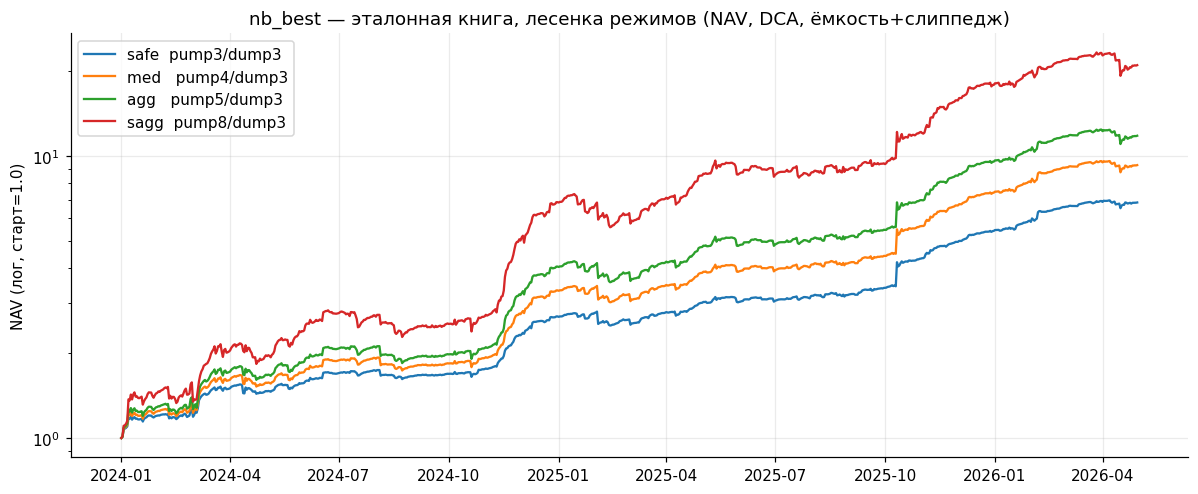

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.6))
for tag, _, _ in TIERS[:4]:
    nav = runs_full[tag]["nav"]
    ax.plot(nav.index, nav.values, label=tag)
ax.set_yscale("log"); ax.set_ylabel("NAV (лог, старт=1.0)"); ax.legend()
ax.set_title("nb_best — эталонная книга, лесенка режимов (NAV, DCA, ёмкость+слиппедж)")
show("comb_best_nav")


## Сверка с боевым paper-ботом (`C:/projects/pump_fade_bot`) — окно 2026-06-28..07-07

Проведена трёхсторонняя сверка на одних данных (Bybit 1m, вселенная бота 120 символов;
артефакты и скрипты — `_out/vs_paperbot_2026-07-07/`):
**live** (логи сервера) ↔ **replay** (код бота на чистых klines, фильтр жив) ↔
**etalon** (машинерия этого нотбука).

| Книга (agg-профиль, $1000, окно 9 дней) | Трейдов | PnL |
|---|---|---|
| live (сервер) | 172 | **−$41** |
| replay (код бота, чистые данные, фильтр вкл) | 127 | **−$57** |
| etalon с фильтром | 245 | **+$86** |
| etalon без фильтра | 393 | **+$375** |

**Данные — не проблема.** live↔replay: 116 общих трейдов, corr(ret) = 0.999,
медианная разница 0.00pp. Расхождения live↔replay целиком операционные: 53 лишних
живых шорта из периода мёртвого памп-фильтра 29.06 02:41–03.07 08:35 (sklearn `_loss`,
дали случайные +$12) и 10 дампов, упущенных live (рестарты/экспозиция, −$11).

**Реализация — та же сделка, но другая книга.** По 102 общим трейдам replay↔etalon
corr(ret) = 0.909, медианно бот ЛУЧШЕ на +0.5pp (вход по close триггер-бара vs
close следующего бара у эталона). Но структурно книги расходятся:

1. **Глубина scale-in.** Бот добирает цель за ≤4 фронт-нагруженных транша
   (ramp 15/30/45/остаток) — средний вход НИЖЕ по памп-ранапу; эталон докупает на
   каждом триггер-баре кластера с растущими весами (до ~26 траншей) — средний вход
   у вершины. Следствие: на раннерах бот ловит стоп −30% там, где эталон доезжает
   до time-выхода (OGNUSDT/MAGMAUSDT 03–04.07: replay −30%, etalon −5…−10%).
2. **Определение события.** Эталон: кластер (10м тишины) → 402 события в окне;
   бот: кулдаун 120м + одна позиция на символ → 127. Из 144 kept-событий эталона,
   которых нет у бота: 79 пришлись на уже открытую позицию бота (влились/заблокированы),
   65 бот вообще не увидел — почти все пампы: **volume-гейт бота сравнивает с медианой
   за 4 часа, эталон — за сутки.** В это окно упущенные события были прибыльными
   (~+1.3…+2.0%/событие).
3. **Перезаход на крэш-днях.** После стопа и 120м кулдауна бот перезаходит в
   продолжающийся обвал (LABUSDT 07.07: лонги −20% и −27% подряд; ARPA/LAB шорты
   −30%) — эталон книжит один кластер. Несколько худших живых трейдов не имеют
   эталонного двойника вообще.
4. **Классификаторы разные** (WF-ретрейн у эталона vs статический pkl у бота):
   12 из 25 replay-only трейдов эталонный фильтр отбросил бы; в этом окне фильтр
   вообще СТОИЛ денег (etalon +86 с ним vs +375 без него; live-авария без фильтра
   дала +$12) — 9-дневный шум на тонком edge, не приговор фильтру.

**Вывод.** Логика бота честная (реплей воспроизводит live с corr 0.999), сигнальное
ядро совпадает с эталоном (corr 0.91), а знак PnL в окне разошёлся из-за трёх
осознанных отличий реализации: мелкий scale-in, узкое определение события
(120м кулдаун + 4ч volume-база) и перезаходы после стопа. Если сближать бота с
эталоном, порядок выгоды в этом окне: (1) volume-база 240м→1440м, (2) блок
перезахода в непрекращающийся дамп (или кулдаун от закрытия, не от входа),
(3) скейл-ин по всему кластеру. Любое из этих изменений — сначала прогнать здесь.

**Как пользоваться нотбуком:** это референс. Меняешь конфиг бота — сначала прогони
изменение здесь (или в новом номерном нотбуке от этой базы), потом переноси.
